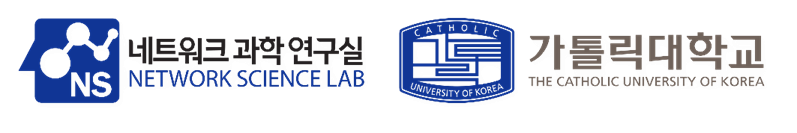

<a target="_blank" href="https://colab.research.google.com/github/NSLab-CUK/Graph-Mining-Spring-2026/blob/main/W12/Sample_Code_12.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [ ]:
!pip install "networkx==2.6.3" "matplotlib==3.5.3" "matplotlib-inline==0.1.6" karateclub scikit-learn seaborn

# Structural Node Embeddings: Role2Vec and GraphWave
**Goal:** Understand how structural embedding algorithms map structurally equivalent nodes to similar points in the embedding space, even if they are far apart in the graph topology.

---
## Part 1: Analyzing a Toy Graph (Barbell Graph)
A Barbell Graph consists of two dense clusters (bells) connected by a long path (bridge). This graph perfectly highlights symmetrically equivalent nodes along the bridge and in the bells.


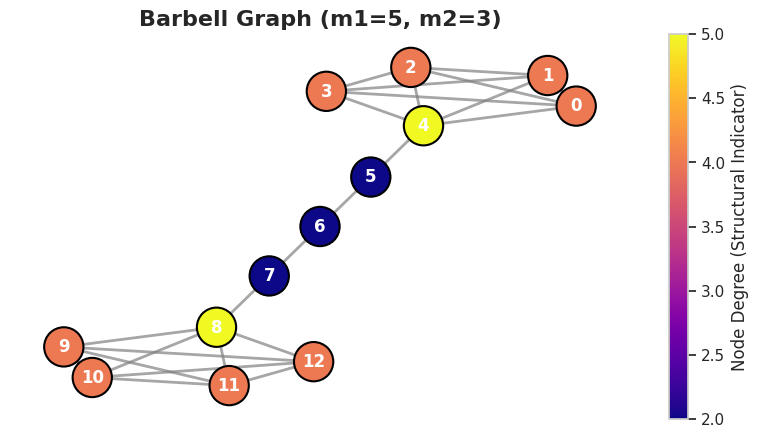

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Apply seaborn aesthetic defaults
sns.set_theme(style="whitegrid", palette="muted")

# 1. Create a Barbell Graph
m1, m2 = 5, 3
G = nx.barbell_graph(m1=m1, m2=m2)

# 2. Extract structural properties for coloring (degree is a simple structural proxy here)
degrees = [deg for node, deg in G.degree()]

# 3. Visualize the original graph
plt.figure(figsize=(10, 5))
pos = nx.kamada_kawai_layout(G)
nodes = nx.draw_networkx_nodes(G, pos, node_color=degrees, cmap='plasma', 
                               node_size=800, edgecolors='black', linewidths=1.5)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=2, alpha=0.7)
nx.draw_networkx_labels(G, pos, font_weight='bold', font_color='white')

plt.colorbar(nodes, label='Node Degree (Structural Indicator)')
plt.title("Barbell Graph (m1=5, m2=3)", fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()

### 1.1 Role2Vec Implementation
Role2Vec generalizes traditional random walks (like DeepWalk) by mapping nodes into structural roles (e.g., using degree sequences). Nodes with the same local structural neighborhood walk patterns will end up closer to each other in the embedding space.

In the resulting 2D space below, notice how the "bridge" nodes and "bell" nodes perfectly cluster according to their structural role, regardless of which side of the barbell they belong.

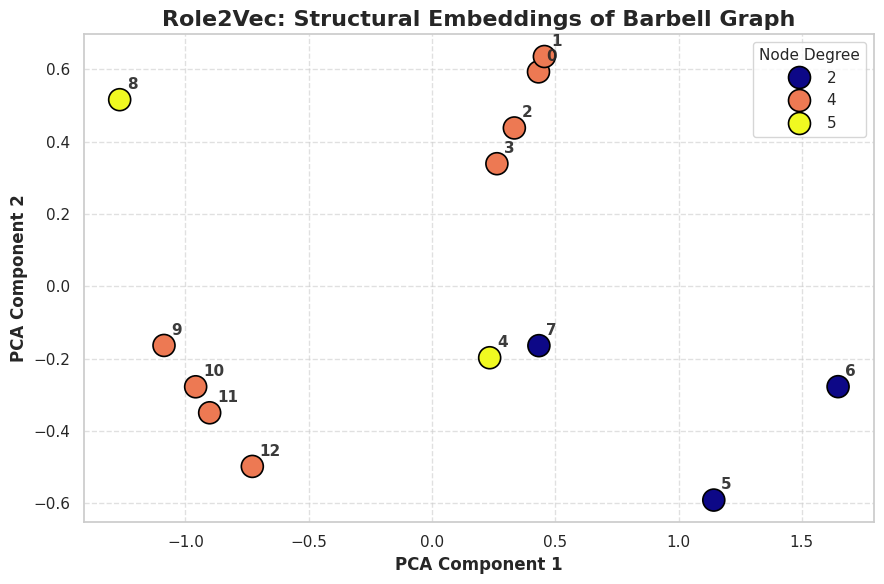

In [2]:
from karateclub import Role2Vec

# 1. Initialize and fit the Role2Vec model
# Karateclub expects nodes to be consecutively indexed starting from 0
r2v_model = Role2Vec(walk_number=10, walk_length=80, dimensions=64, seed=42)
r2v_model.fit(G)

# 2. Extract the embeddings (Shape: Number of Nodes x 64 Dimensions)
r2v_embeddings = r2v_model.get_embedding()

# 3. Reduce dimensionality to 2D for visualization using PCA
pca = PCA(n_components=2, random_state=42)
r2v_2d = pca.fit_transform(r2v_embeddings)

# 4. Plot the results with seaborn enhancements
plt.figure(figsize=(9, 6))

# Color by our basic proxy for structure: node degree
scatter = sns.scatterplot(
    x=r2v_2d[:, 0], y=r2v_2d[:, 1], hue=degrees, palette="plasma",
    s=250, edgecolor="black", linewidth=1.2, zorder=5
)

# Annotate each point for clarity
for i, txt in enumerate(G.nodes()):
    plt.annotate(str(txt), (r2v_2d[i, 0] + 0.03, r2v_2d[i, 1] + 0.03), 
                 fontsize=11, fontweight='bold', alpha=0.9, zorder=10)

plt.title("Role2Vec: Structural Embeddings of Barbell Graph", fontsize=16, fontweight='bold')
plt.xlabel("PCA Component 1", fontsize=12, fontweight='bold')
plt.ylabel("PCA Component 2", fontsize=12, fontweight='bold')
plt.legend(title='Node Degree', title_fontsize='11', loc='best', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 1.2 GraphWave Implementation
Unlike random walk approaches, GraphWave analyzes how spectral heat diffuses across a graph locally. This method is mathematically designed to be purely structural - it doesn't care about the labels, only the geometric "shape" of the node's neighborhood.

Notice how it provides extremely tight clusters for computationally equivalent nodes (e.g., all identical "bell" nodes overlap perfectly, while bridge nodes separate distinctly based on distance from the bells).

2026-05-18 23:10:44,081:[WARNING](pygsp.graphs.graph.__init__): Adjacency: there are self-loops (non-zeros on the diagonal). The Laplacian will not see them.


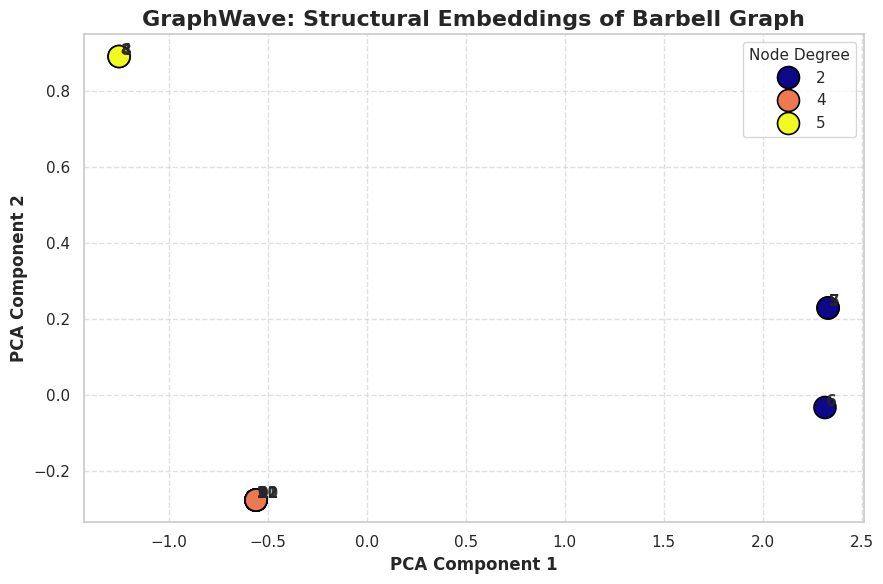

In [3]:
import warnings

# Suppress minor library warnings for cleaner output
warnings.filterwarnings("ignore", category=UserWarning)

from karateclub import GraphWave

# 1. Initialize and fit the GraphWave model
# mechanism='approximate' is faster for large graphs, 'exact' is good for small graphs like ours
gwave_model = GraphWave(mechanism='exact')
gwave_model.fit(G)

# 2. Extract the embeddings
gwave_embeddings = gwave_model.get_embedding()

# 3. Reduce dimensionality to 2D for visualization
gwave_2d = pca.fit_transform(gwave_embeddings)

# 4. Plot the results
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=gwave_2d[:, 0], y=gwave_2d[:, 1], hue=degrees, palette="plasma",
    s=250, edgecolor="black", linewidth=1.2, zorder=5
)

# Text annotation, slight jitter for overlapping points if any
for i, txt in enumerate(G.nodes()):
    plt.annotate(str(txt), (gwave_2d[i, 0] + 0.005, gwave_2d[i, 1] + 0.005), 
                 fontsize=11, fontweight='bold', alpha=0.9, zorder=10)

plt.title("GraphWave: Structural Embeddings of Barbell Graph", fontsize=16, fontweight='bold')
plt.xlabel("PCA Component 1", fontsize=12, fontweight='bold')
plt.ylabel("PCA Component 2", fontsize=12, fontweight='bold')
plt.legend(title='Node Degree', title_fontsize='11', loc='best', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

---
## Part 2: Complex Geometry (Mirrored Karate Club Graph)

To push these models further, we'll create a highly complex, symmetrical graph by duplicating the famous Zachary's Karate Club graph. 
We connect the original (Nodes 0-33) and its exact clone (Nodes 34-67) via a single edge between Node 0 and its identical twin, Node 34.

This gives us the perfect testbed: Does node `X` from the first club map to the exact same position in embedding space as its twin `X + 34` in the second club?

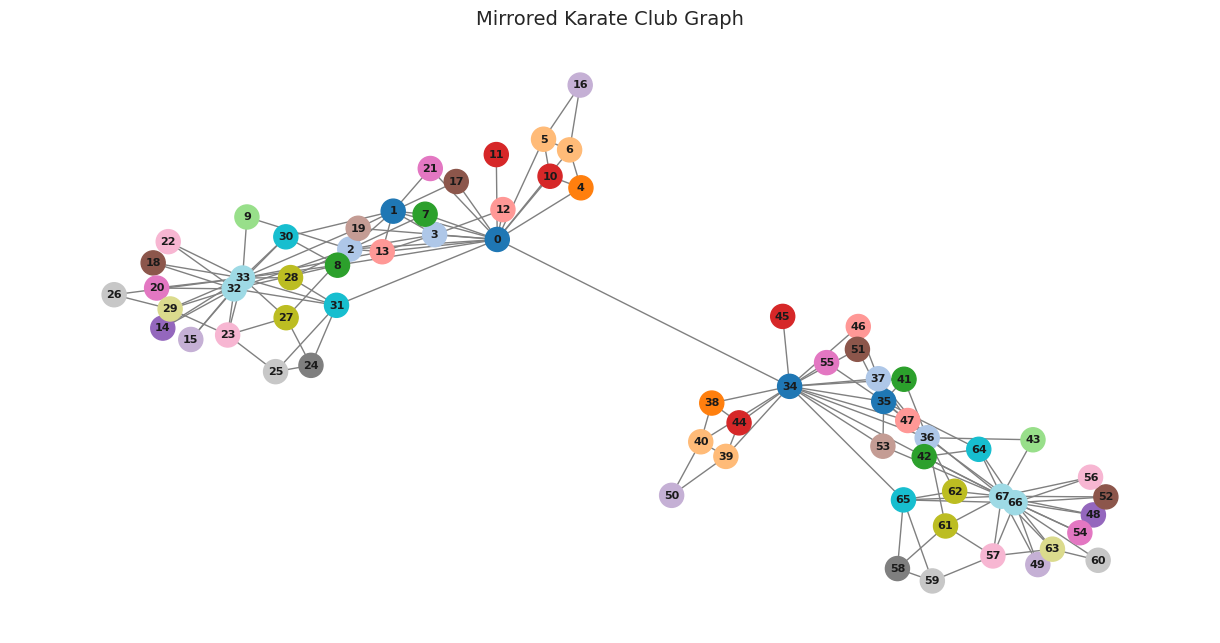

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Load the base graph
G_karate = nx.karate_club_graph()

# 2. Mirror it by taking the disjoint union of two Karate Club graphs
# Nodes 0-33 belong to the original. Nodes 34-67 are their respective twins.
G_mirrored = nx.disjoint_union(G_karate, G_karate)

# 3. Connect them symmetrically to form a single connected component.
# Connecting Node 0 (Mr. Hi) of the first to Node 34 (Mr. Hi's twin in the second)
G_mirrored.add_edge(0, 34)

# 4. Visualization setup
# We color structurally identical nodes identically (e.g., Node 1 and Node 35 get the same color)
colors = [n % 34 for n in G_mirrored.nodes()]

plt.figure(figsize=(12, 6))
pos = nx.spring_layout(G_mirrored, seed=42)
nx.draw(G_mirrored, pos, node_color=colors, cmap='tab20', 
        with_labels=True, node_size=300, font_size=8, font_weight='bold', edge_color='gray')
plt.title("Mirrored Karate Club Graph", fontsize=14)
plt.show()

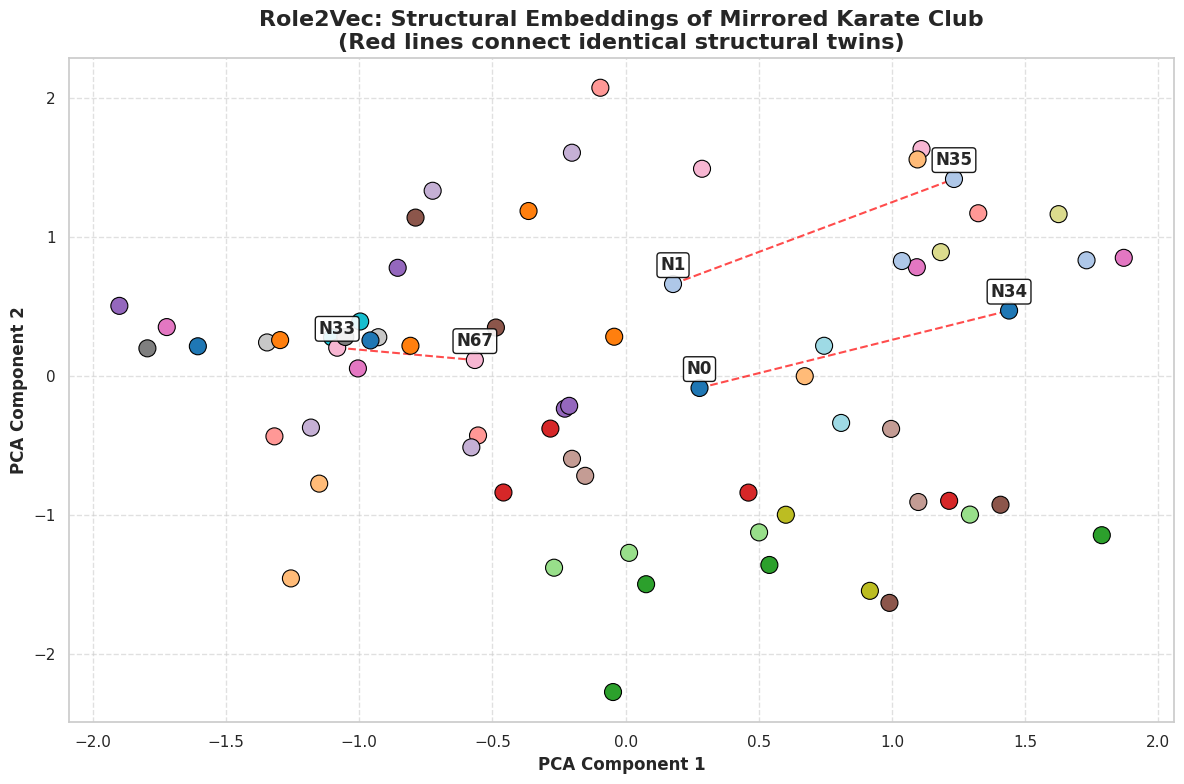

In [5]:
# 1. Fit Role2Vec
r2v_model = Role2Vec(walk_number=10, walk_length=80, dimensions=64, seed=42)
r2v_model.fit(G_mirrored)

# 2. Extract Embeddings
r2v_embeddings = r2v_model.get_embedding()

# 3. PCA Projection
pca_mirror = PCA(n_components=2, random_state=42)
r2v_2d = pca_mirror.fit_transform(r2v_embeddings)

# 4. Plot the results
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=r2v_2d[:, 0], y=r2v_2d[:, 1], hue=colors, palette="tab20",
    s=150, edgecolor="black", linewidth=0.8, legend=False, zorder=5
)

# Annotate a few key twin pairs to explicitly show how they map together
# Mr Hi (0, 34), John A (33, 67), and Node (1, 35)
key_nodes = [0, 34, 33, 67, 1, 35] 

for node in key_nodes:
    plt.annotate(
        f"N{node}", (r2v_2d[node, 0], r2v_2d[node, 1]), 
        textcoords="offset points", xytext=(0,10), ha='center',
        fontsize=12, weight='bold', 
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", lw=1, alpha=0.9), zorder=10
    )
    
# Draw lines between these key twin pairs to highlight their proximity in embedded space!
twin_pairs = [(0, 34), (33, 67), (1, 35)]
for u, v in twin_pairs:
    plt.plot([r2v_2d[u, 0], r2v_2d[v, 0]], [r2v_2d[u, 1], r2v_2d[v, 1]], 
             color='red', linestyle='--', linewidth=1.5, zorder=1, alpha=0.7)

plt.title("Role2Vec: Structural Embeddings of Mirrored Karate Club\n(Red lines connect identical structural twins)", 
          fontsize=16, fontweight='bold')
plt.xlabel("PCA Component 1", fontsize=12, fontweight='bold')
plt.ylabel("PCA Component 2", fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

2026-05-18 23:10:46,696:[WARNING](pygsp.graphs.graph.__init__): Adjacency: there are self-loops (non-zeros on the diagonal). The Laplacian will not see them.


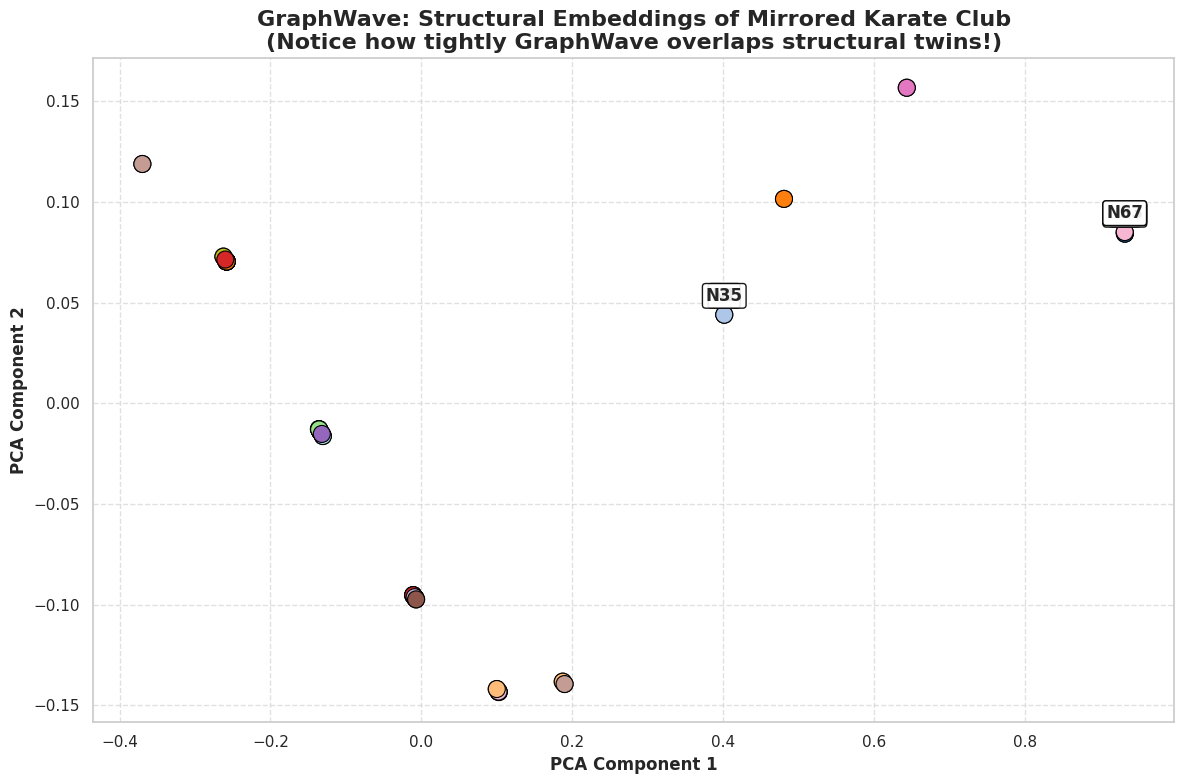

In [6]:
# 1. Fit GraphWave
# Using 'exact' is mathematically perfect for capturing this symmetry on smaller graphs
gwave_model = GraphWave(mechanism='exact')
gwave_model.fit(G_mirrored)

# 2. Extract Embeddings
gwave_embeddings = gwave_model.get_embedding()

# 3. PCA Projection
gwave_2d = pca_mirror.fit_transform(gwave_embeddings)

# 4. Plot the results
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=gwave_2d[:, 0], y=gwave_2d[:, 1], hue=colors, palette="tab20",
    s=150, edgecolor="black", linewidth=0.8, legend=False, zorder=5
)

# Highlight twins again
for node in key_nodes:
    plt.annotate(
        f"N{node}", (gwave_2d[node, 0], gwave_2d[node, 1]), 
        textcoords="offset points", xytext=(0,10), ha='center',
        fontsize=12, weight='bold', 
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", lw=1, alpha=0.9), zorder=10
    )

# Draw connections
for u, v in twin_pairs:
    plt.plot([gwave_2d[u, 0], gwave_2d[v, 0]], [gwave_2d[u, 1], gwave_2d[v, 1]], 
             color='red', linestyle='--', linewidth=1.5, zorder=1, alpha=0.7)

plt.title("GraphWave: Structural Embeddings of Mirrored Karate Club\n(Notice how tightly GraphWave overlaps structural twins!)", 
          fontsize=16, fontweight='bold')
plt.xlabel("PCA Component 1", fontsize=12, fontweight='bold')
plt.ylabel("PCA Component 2", fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()